In [21]:
import tensorflow as tf
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, RNN, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
!wget 


In [22]:
data = pd.read_csv('Preprocessed/Preprocessed_data.csv')
data.head()


,Comp,Day,Venue,GF,GA,Team,Opponent,xGA,Poss,Attendance,...,O_In,O_Out,O_Str,O_Off,O_CPA,O_CrdY,O_CrdR,O_Fls,FTR,weight
0,24,0,1,2,0,0,0,0.3,77.0,30415.0,...,2.0,1.0,0.0,6.0,1.0,0.0,0.0,6.0,0.0,0.131153
1,24,1,0,1,1,0,1,0.6,64.0,49108.0,...,0.0,1.0,0.0,3.0,1.0,4.0,1.0,9.0,0.0,0.131579
2,24,0,1,2,1,0,2,0.5,70.0,10419.0,...,2.0,0.0,0.0,0.0,0.0,5.0,0.0,13.0,1.0,0.131817
3,24,0,0,5,0,0,3,0.7,66.0,54172.0,...,3.0,0.0,0.0,2.0,6.0,2.0,1.0,9.0,0.0,0.132486
4,4,2,1,4,0,0,4,0.3,71.0,43500.0,...,2.0,1.0,0.0,3.0,1.0,4.0,0.0,14.0,2.0,0.132679


In [23]:
data_mr = data[['Comp', 'Day', 'Venue', 'Team',
                'Opponent', 'Referee', 'FTR', 'weight']]


data.drop(['Comp', 'Day', 'Venue', 'Team',
           'Opponent', 'Referee', 'FTR', 'weight'], axis=1, inplace=True)


In [24]:
data.head()


,GF,GA,xGA,Poss,Attendance,SoT,xG.1,Saves,CS,CPA,...,O_TI,O_CK,O_In,O_Out,O_Str,O_Off,O_CPA,O_CrdY,O_CrdR,O_Fls
0,2,0,0.3,77.0,30415.0,4.0,1.9,2.0,1.0,3.0,...,18.0,3.0,2.0,1.0,0.0,6.0,1.0,0.0,0.0,6.0
1,1,1,0.6,64.0,49108.0,6.0,1.1,1.0,0.0,7.0,...,31.0,1.0,0.0,1.0,0.0,3.0,1.0,4.0,1.0,9.0
2,2,1,0.5,70.0,10419.0,8.0,1.4,2.0,0.0,6.0,...,19.0,2.0,2.0,0.0,0.0,0.0,0.0,5.0,0.0,13.0
3,5,0,0.7,66.0,54172.0,10.0,2.4,3.0,1.0,7.0,...,17.0,3.0,3.0,0.0,0.0,2.0,6.0,2.0,1.0,9.0
4,4,0,0.3,71.0,43500.0,7.0,1.3,1.0,1.0,5.0,...,17.0,3.0,2.0,1.0,0.0,3.0,1.0,4.0,0.0,14.0


In [25]:
ss = StandardScaler()
data.iloc[:, :] = ss.fit_transform(data.iloc[:, :])


In [26]:
df = pd.concat([data, data_mr], axis=1)
df.shape


(31158, 43)

In [27]:
df.head()


,GF,GA,xGA,Poss,Attendance,SoT,xG.1,Saves,CS,CPA,...,O_CrdR,O_Fls,Comp,Day,Venue,Team,Opponent,Referee,FTR,weight
0,0.185614,-0.989754,-1.193082,2.324318,0.557079,-0.325190,0.347814,-0.317073,1.310988,-0.556132,...,-0.347841,-1.618944,24,0,1,0,0,0,0.0,0.131153
1,-0.540573,-0.010279,-0.740522,0.984823,1.742495,0.451378,-0.578372,-0.877106,-0.762906,0.809592,...,2.492316,-0.902403,24,1,0,0,1,1,0.0,0.131579
2,0.185614,-0.010279,-0.891375,1.603051,-0.710967,1.227947,-0.231052,-0.317073,-0.762906,0.468161,...,-0.347841,0.052985,24,0,1,0,2,2,1.0,0.131817
3,2.364174,-0.989754,-0.589668,1.190899,2.063629,2.004516,0.926681,0.242959,1.310988,0.809592,...,2.492316,-0.902403,24,0,0,0,3,3,0.0,0.132486
4,1.637987,-0.989754,-1.193082,1.706089,1.386864,0.839663,-0.346826,-0.877106,1.310988,0.126730,...,-0.347841,0.291832,4,2,1,0,4,4,2.0,0.132679


In [28]:
data = pd.get_dummies(
    df, columns=['Comp', 'Day', 'Venue', 'Team', 'Opponent', 'Referee'], dtype=int)


In [29]:
data.shape


(31158, 2169)

In [30]:
x_train, x_test, y_train, y_test = train_test_split(
    data.drop('FTR', axis=1), data['FTR'], random_state=40, test_size=0.2)


In [31]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
acs = accuracy_score(y_test, y_pred)


c:\Users\moomad\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [32]:
acs


0.5309691912708601

In [33]:
conma = confusion_matrix(y_test, y_pred)
conma


array([[1856,  425,  470],
       [ 671,  442,  403],
       [ 724,  230, 1011]], dtype=int64)

In [34]:
clf = classification_report(y_test, y_pred)
print(clf)


              precision    recall  f1-score   support

         0.0       0.57      0.67      0.62      2751
         1.0       0.40      0.29      0.34      1516
         2.0       0.54      0.51      0.53      1965

    accuracy                           0.53      6232
   macro avg       0.50      0.49      0.49      6232
weighted avg       0.52      0.53      0.52      6232



Deep Learning Model


In [35]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
y_test


array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       ...,
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [36]:
x_train.head()


,GF,GA,xGA,Poss,Attendance,SoT,xG.1,Saves,CS,CPA,...,Referee_1017,Referee_1021,Referee_1022,Referee_1023,Referee_1025,Referee_1026,Referee_1027,Referee_1029,Referee_1030,Referee_1031
17158,-0.540573,0.969195,-1.343935,1.603051,-1.321590,0.063094,-0.346826,-1.437138,-0.762906,1.151023,...,0,0,0,0,0,0,0,0,0,0
6135,-1.266760,0.969195,0.013745,1.190899,0.000078,2.004516,0.116267,0.242959,-0.762906,0.468161,...,0,0,0,0,0,0,0,0,0,0
18072,-0.540573,-0.989754,1.974839,-2.930625,0.000078,-1.490044,0.347814,-0.317073,1.310988,-0.214701,...,0,0,0,0,0,0,0,0,0,0
30613,1.637987,-0.010279,1.371425,-1.591130,0.459610,0.063094,-0.115279,0.802992,-0.762906,0.126730,...,0,0,0,0,0,0,0,0,0,0
1352,-1.266760,-0.010279,-0.287962,0.057480,-0.146066,-1.490044,-0.694146,0.242959,-0.762906,-0.214701,...,0,0,0,0,0,0,0,0,0,0


In [37]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(Dropout(0.5))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(8, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

early_stopping = EarlyStopping(monitor='val_loss', patience=10)

# model = Sequential()
# model.add(Dense(128, activation='relu', input_shape=(x_train.shape[1],)))
# # model.add(Dense(128, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(64, activation='relu'))
# model.add(Dropout(0.5))
# model.add(BatchNormalization())
# model.add(Dense(32, activation='relu'))
# model.add(Dense(3, activation='softmax'))
# model.compile(optimizer='adam', loss='categorical_crossentropy',
#               metrics=['accuracy'])
# history = model.fit(x_train, y_train, epochs=70,
#                     batch_size=32, validation_data=(x_test, y_test), validation_split=0.2)


In [38]:
model.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])


In [39]:
history = model.fit(x_train, y_train, epochs=150,
                    batch_size=32, validation_data=(x_test, y_test),
                    # validation_split=0.2,
                    callbacks=[early_stopping]
                    )


Epoch 1/150
779/779 [==============================] - 12s 8ms/step - loss: 1.0713 - accuracy: 0.4297 - val_loss: 1.0411 - val_accuracy: 0.4418
Epoch 2/150
779/779 [==============================] - 5s 6ms/step - loss: 1.0318 - accuracy: 0.4545 - val_loss: 0.9229 - val_accuracy: 0.5642
Epoch 3/150
779/779 [==============================] - 6s 7ms/step - loss: 0.9407 - accuracy: 0.5423 - val_loss: 0.8027 - val_accuracy: 0.6999
Epoch 4/150
779/779 [==============================] - 5s 7ms/step - loss: 0.8616 - accuracy: 0.6062 - val_loss: 0.7341 - val_accuracy: 0.7271
Epoch 5/150
779/779 [==============================] - 5s 6ms/step - loss: 0.8250 - accuracy: 0.6415 - val_loss: 0.7007 - val_accuracy: 0.7402
Epoch 6/150
779/779 [==============================] - 5s 6ms/step - loss: 0.7803 - accuracy: 0.6781 - val_loss: 0.6627 - val_accuracy: 0.7572
Epoch 7/150
779/779 [==============================] - 5s 7ms/step - loss: 0.7617 - accuracy: 0.6901 - val_loss: 0.6654 - val_accuracy: 0.749

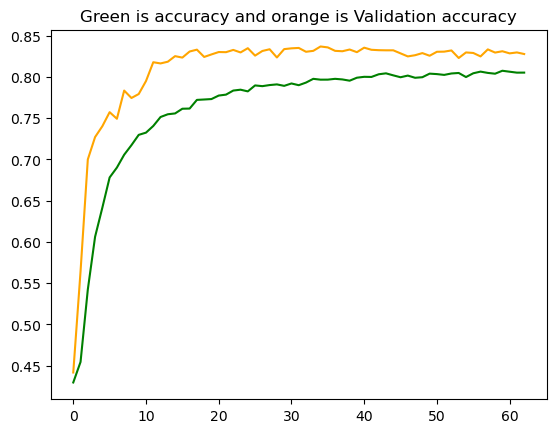

In [40]:
plt.plot(history.history['accuracy'], color='green', label='Train Data')
plt.title("Green is accuracy and orange is Validation accuracy")
plt.plot(history.history['val_accuracy'],
         color='orange', label='Validation Data')


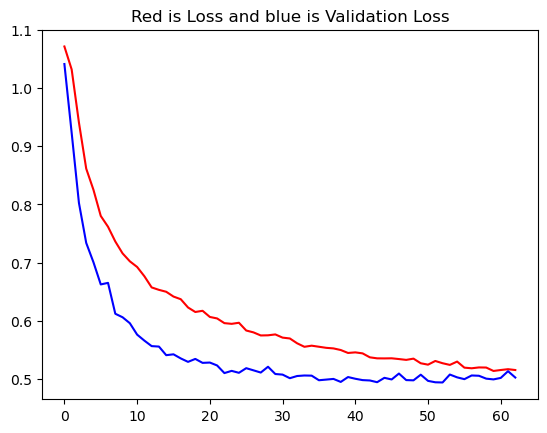

In [41]:
plt.plot(history.history['loss'], color='red')
plt.title("Red is Loss and blue is Validation Loss")
plt.plot(history.history['val_loss'], color='blue')


In [ ]:
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from sklearn.metrics import accuracy_score

# Define your Keras model as a function


def create_model(optimizer='adam', activation='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Dense(256, activation=activation,
              input_shape=(x_train.shape[1],)))
    model.add(BatchNormalization())
    model.add(Dense(128, activation=activation))
    model.add(Dense(64, activation=activation))
    model.add(Dense(32, activation=activation))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


# Create KerasClassifier wrapper for GridSearchCV compatibility
model = KerasClassifier(build_fn=create_model,
                        activation='relu', dropout_rate=0.0, verbose=0)

# Define the grid search parameters
param_grid = {
    'optimizer': ['adam', 'rmsprop'],
    'activation': ['relu', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

# Instantiate GridSearchCV
grid_search = GridSearchCV(
    estimator=model, param_grid=param_grid, cv=3, scoring='accuracy')

# Fit GridSearchCV
grid_search.fit(x_train, y_train)

# Access best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy score: ", grid_search.best_score_)
print("Best error score: ", grid_search.error_score)


# Predict on test set using the best model
y_pred = grid_search.predict(x_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print("Test accuracy: ", accuracy)


Reinforcement Learning Part


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.optimizers import Adam

# Assuming x_train, y_train, x_test, y_test are already defined and preprocessed.

model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(x_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(16, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

early_stopping = EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True)

initial_learning_rate = 0.001
lr_schedule = LearningRateScheduler(
    lambda epoch: initial_learning_rate * 0.95 ** epoch)
optimizer = Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy', metrics=['accuracy'])

# reward function


def reward_function(y_true, y_pred):
    if isinstance(y_true, pd.Series) or isinstance(y_true, pd.DataFrame):
        y_true = y_true.values

    if y_true.ndim == 1:
        y_true = np.expand_dims(y_true, axis=-1)

    if y_pred.ndim == 1:
        y_pred = np.expand_dims(y_pred, axis=-1)

    reward = np.where(np.argmax(y_true, axis=1) ==
                      np.argmax(y_pred, axis=1), 1, -1)
    return reward


loss_function = tf.keras.losses.CategoricalCrossentropy()

if isinstance(x_train, pd.DataFrame):
    x_train = tf.convert_to_tensor(x_train.values)

for epoch in range(500):
    with tf.GradientTape() as tape:
        predictions = model(x_train, training=True)
        loss_value = loss_function(y_train, predictions)

    rewards = reward_function(y_train, predictions)
    grads = tape.gradient(loss_value, model.trainable_variables)

    for grad, reward in zip(grads, rewards):
        grad *= reward

    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    print(f'Epoch {epoch+1}, Loss: {loss_value.numpy()}')

    if early_stopping.stopped_epoch > 0:
        break

history = {
    'loss': [],
    'accuracy': [],
    'val_loss': [],
    'val_accuracy': []
}

val_loss, val_accuracy = model.evaluate(x_test, y_test, verbose=0)
history['val_loss'].append(val_loss)
history['val_accuracy'].append(val_accuracy)


print("Final Loss:", val_loss)
print("Final Accuracy:", val_accuracy)


In [ ]:
epoch30 = {'Final Loss': 1.0964429378509521,
           'Final Accuracy': 0.31752893328666687}  # 30epoch
eopch1000 = {'Final Loss': 0.23927436769008636,
             'Final Accuracy': 0.9313738346099854}


In [ ]:
import numpy as np

# Define the football match environment


import pandas as pd


class FootballMatchEnvironment:
    def __init__(self, matches_df, initial_state):
        self.matches_df = matches_df
        self.current_match_index = 0
        self.initial_state = initial_state

    def reset(self):
        self.current_match_index = 0
        return self.initial_state

    def step(self, action):
        # Convert matches_df to pandas DataFrame if it's not already
        if isinstance(self.matches_df, pd.DataFrame):
            match_row = self.matches_df.iloc[self.current_match_index]
        else:
            # Handle TensorFlow tensor conversion to DataFrame if matches_df is a tensor
            match_row = pd.DataFrame(
                self.matches_df.numpy()).iloc[self.current_match_index]

        # Assuming 'FTR' is the column name for actual outcomes
        actual_outcome = match_row['FTR']
        reward = 1 if action == actual_outcome else 0
        self.current_match_index += 1
        done = self.current_match_index >= len(self.matches_df)

        # Assuming 'FTR' is the column to drop
        next_state = match_row.drop(columns=['FTR']).values
        return next_state, reward, done


# Define the Q-learning agent


class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.q_table = np.zeros((state_size, action_size))
        self.discount_factor = 0.99
        self.learning_rate = 0.1

    def choose_action(self, state):
        # Convert state to integer index if necessary
        state_index = int(state) if isinstance(state, float) else state
        return np.argmax(self.q_table[state_index, :])

    def update_q_table(self, state, action, reward, next_state):
        # Convert next_state to integer index if necessary
        next_state_index = int(next_state) if isinstance(
            next_state, float) else next_state

        best_next_action = np.argmax(self.q_table[next_state_index, :])
        td_target = reward + self.discount_factor * \
            self.q_table[next_state_index, best_next_action]
        td_error = td_target - self.q_table[state, action]
        self.q_table[state, action] += self.learning_rate * td_error


# Initialize the football match environment
matches = [...]  # List of dictionaries with features and actual outcomes
# Initial state vector representing features of the first match
initial_state = [0, 0, 0]
env = FootballMatchEnvironment(data.iloc[:, 1:], initial_state)

# Initialize the Q-learning agent
state_size = len(initial_state)
action_size = 3  # Assuming three actions: win, lose, draw
agent = DQNAgent(state_size, action_size)

# Training loop
num_episodes = 1000
for episode in range(num_episodes):
    state = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = agent.choose_action(state)
        next_state, reward, done = env.step(action)
        agent.update_q_table(state, action, reward, next_state)
        total_reward += reward
        state = next_state
    print(f"Episode {episode + 1}, Total Reward: {total_reward}")

# Evaluate the trained agent (similar to training loop but without updating Q-table)


In [23]:
y_pred = model.predict(x_test)
np.argmax(y_pred[2])
y_pred


470/470 [==============================] - 3s 7ms/step


array([[9.9605250e-01, 3.8161769e-03, 1.3136184e-04],
       [9.9450642e-01, 4.8432699e-03, 6.5022556e-04],
       [7.3251551e-01, 2.5891352e-01, 8.5710054e-03],
       ...,
       [8.5310924e-01, 1.3414535e-01, 1.2745393e-02],
       [8.5548788e-01, 1.2929159e-01, 1.5220541e-02],
       [3.2575097e-02, 8.6889410e-01, 9.8530784e-02]], dtype=float32)

In [42]:
model.save('FinalData.h5', 'wb')


c:\Users\moomad\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
nl = data.columns.to_list()


In [ ]:
import seaborn as sns
for i in data.columns.to_list():
    print(f'Plot for {i} at below')
    sns.histplot(data[i])
    plt.show()
